In [258]:
from experiments import (
    load_selfplay_results,
    load_tournament_results
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [259]:
from pathlib import Path


scores = load_selfplay_results (Path("../../results/sp/pd"), 0.05)
# Filter to only include rows where Player index equals Opponent index (self-play)
scores = scores[scores['Player index'] == scores['Opponent index']]
scores = scores[scores['Player index'] == 7].sort_values('repetition')


In [260]:
scores.head(10)

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,CC to D count,CD to C count,CD to D count,DC to C count,DC to D count,DD to C count,DD to D count,Good partner,Intended Actions,repetition
98,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDCDDDDDDCDCDCDCDCDCDDCCCCCCCCCCCCCCDCDCDCDC...,2715,60,1000,...,45,16,91,55,64,82,19,0,DDDDDDDDDDDCDCDCDCDCDCDDCCCCCCCCCCCCCCDCDCDCCC...,0
99,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDDDDDDCDCDCDCDCDDCDCCCCCCCCCCCCCDCDCDCCCD...,2655,-60,1000,...,44,27,92,60,47,77,24,1,DDDDDDDDDDDCDCDCDCDCDCCDCCCCCCCCCCCCCCCDCDCDCD...,0
208,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDDDDDDCDCDCDCDCDCCCCCCCCCDCDDCDDCDDCDDDDD...,1494,295,1000,...,14,12,58,10,119,62,714,0,DDDDDDDDDDDCDCDCDCDCDCCCCCCCCCCCDDCDDCDDCDDDDD...,1
209,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDCDDCDCDCDCDCDCDCCCCCCCCCCDDCDDCDDCDCDCDC...,1199,-295,1000,...,8,16,113,8,62,113,663,1,DDDDDDDDDDDCDCDCDCDCDCCCCCCCCCCDDCDDCDDCDCDCDC...,1
1418,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDCCDDDCDCDDCCDCDDDCDDCDDCDCDCDCDCDCDCDCDD...,995,-1155,1000,...,30,33,252,10,44,272,356,1,DDDDDDDDDDDCDCDDDCDCDDDCDDCDDCDCDCDCDCDCDCDCDC...,2
1419,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDDDDDDCDCCCDDDCCCDCCDDCDCCDDCDCDCDCDCCDDC...,2150,1155,1000,...,23,14,40,22,263,41,587,0,DDDDDDDDDDDCDCDCDDDCDCDCCDCCDCCDDCDCDCDCDCCDDC...,2
2628,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DCDDDDDDDDCCDCDCDCDCDCCDDCCCCCCDCDCDCDCDCDDCCC...,1193,-610,1000,...,13,28,171,22,55,162,519,1,DDDDDDDDDDDCDCDCDCDCDCCDDCCCCCCCCDCDCDCDCDDCCC...,3
2629,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDCCDDDDDDDCDCDCDCDCDCDCDCCCCCCCDCDCDCDCDCDCCC...,1803,610,1000,...,16,12,65,19,180,62,619,0,DDDDDDDDDDDCDCDCDCDCDCCCDCCCCCCCDCDCDCDCDCDCCC...,3
2738,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDDDDCDCDCDCDCDCCCDCCCDCDCCCCCCCCCCCCCCCCC...,1990,-300,1000,...,266,35,127,58,44,335,28,1,DDDDDDDDDDDCDCDCDCDCDCDCCCCCDCCCCCCCCCCCCCCCCC...,4
2739,49,7,7,0,"ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...","ActiveInferenceAgent: 5, 10, 42, 1, 1, 1, 0.5,...",DDDDDDDDDDDCDCDCDCDCDDDCCCCDDCCCCCCCCCCCCCCCCC...,2290,300,1000,...,296,26,76,39,123,333,30,0,DDDDDDDDDDDCDCDCDCDCDDDCCCCDDCCCCCCCCCCCCCCCCC...,4


In [261]:
# Extract action sequences for self-play matches
# Since there's only one type of player index, we can directly use the scores
result_table = (
    scores
    .assign(player_num=lambda df: df.groupby(['repetition', 'Interaction index']).cumcount() + 1)
    .pivot_table(
        index='repetition',
        columns='player_num',
        values='Actions',
        aggfunc='first'
    )
    .rename(columns={1: 'agent1_actions', 2: 'agent2_actions'})
    .reset_index()
)

result_table.head()


player_num,repetition,agent1_actions,agent2_actions
0,0,DDDDCDDDDDDCDCDCDCDCDCDDCCCCCCCCCCCCCCDCDCDCDC...,DDDDDDDDDDDCDCDCDCDCDDCDCCCCCCCCCCCCCDCDCDCCCD...
1,1,DDDDDDDDDDDCDCDCDCDCDCCCCCCCCCDCDDCDDCDDCDDDDD...,DDDDDDCDDCDCDCDCDCDCDCCCCCCCCCCDDCDDCDDCDCDCDC...
2,2,DDDDDDCCDDDCDCDDCCDCDDDCDDCDDCDCDCDCDCDCDCDCDD...,DDDDDDDDDDDCDCCCDDDCCCDCCDDCDCCDDCDCDCDCDCCDDC...
3,3,DCDDDDDDDDCCDCDCDCDCDCCDDCCCCCCDCDCDCDCDCDDCCC...,DDCCDDDDDDDCDCDCDCDCDCDCDCCCCCCCDCDCDCDCDCDCCC...
4,4,DDDDDDDDDCDCDCDCDCDCCCDCCCDCDCCCCCCCCCCCCCCCCC...,DDDDDDDDDDDCDCDCDCDCDDDCCCCDDCCCCCCCCCCCCCCCCC...


In [262]:
print(len(result_table['agent1_actions'].iloc[0]))

1000


In [263]:
# Build the joint-actions dataframe: timestep, repetition, joint state (CC/DD/CD/DC)
joint_actions_df = (
    result_table
    .assign(
        timestep=lambda df: df.apply(
            lambda r: list(range(min(len(r['agent1_actions']), len(r['agent2_actions'])))), axis=1
        )
    )
    .explode('timestep')
    .assign(
        player=lambda df: df.apply(lambda r: r['agent1_actions'][r['timestep']], axis=1),
        opponent=lambda df: df.apply(lambda r: r['agent2_actions'][r['timestep']], axis=1),
        joint_state=lambda df: df['player'] + df['opponent']
    )
    [['timestep', 'repetition', 'joint_state']]
    .reset_index(drop=True)
)

joint_actions_df.head()

player_num,timestep,repetition,joint_state
0,0,0,DD
1,1,0,DD
2,2,0,DD
3,3,0,DD
4,4,0,CD


In [264]:
# Group by timestep aggregating joint state by mode over repetitions
most_common_states = (
    joint_actions_df
    .groupby(['timestep'])['joint_state']
    .agg(lambda x: x.mode().iloc[0])  # Get the most frequent state for each timestep
    .reset_index()
    .rename(columns={'joint_state': 'most_common_joint_state'})
)

most_common_states.shape

(1000, 2)

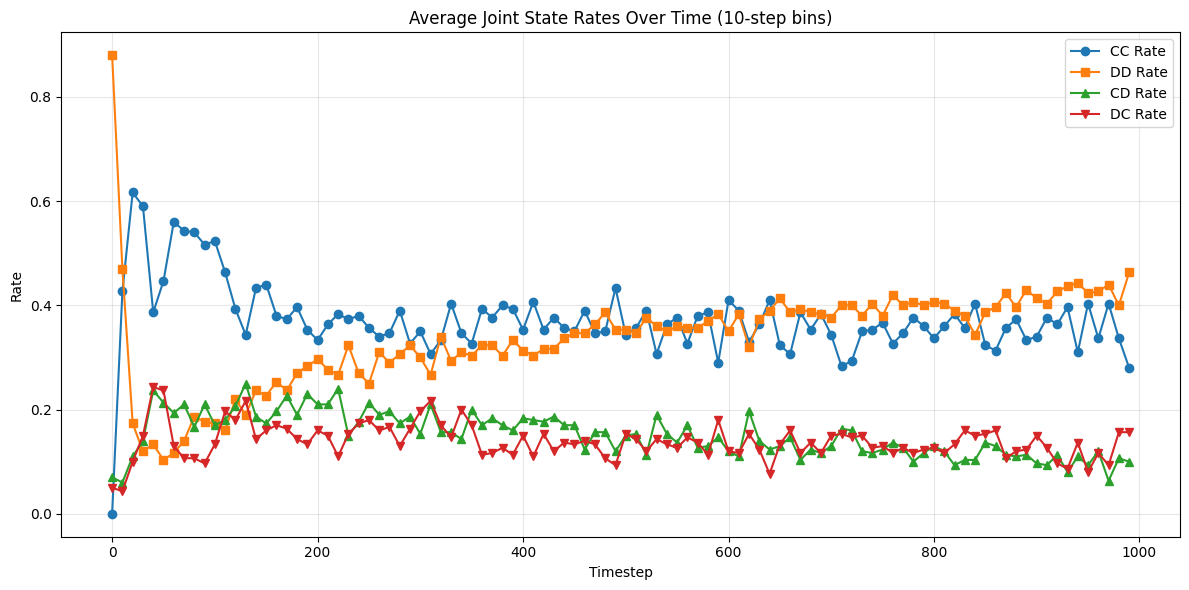

In [265]:
# now we have a table with timestep and state, can we plot the average CC Rate vs DD rate over time? We can do this by aggregating 10 step intervals
bin_size = 10
cc_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'CC').mean())
    .reset_index(name='cc_rate')
    .groupby('bin')['cc_rate']
    .mean()
    .reset_index()
)

dd_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'DD').mean())
    .reset_index(name='dd_rate')
    .groupby('bin')['dd_rate']
    .mean()
    .reset_index()
)

cd_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'CD').mean())
    .reset_index(name='cd_rate')
    .groupby('bin')['cd_rate']
    .mean()
    .reset_index()
)

dc_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'DC').mean())
    .reset_index(name='dc_rate')
    .groupby('bin')['dc_rate']
    .mean()
    .reset_index()
)

# Plot CC, DD, CD, and DC rates over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cc_rates['bin'] * bin_size, cc_rates['cc_rate'], label='CC Rate', marker='o')
ax.plot(dd_rates['bin'] * bin_size, dd_rates['dd_rate'], label='DD Rate', marker='s')
ax.plot(cd_rates['bin'] * bin_size, cd_rates['cd_rate'], label='CD Rate', marker='^')
ax.plot(dc_rates['bin'] * bin_size, dc_rates['dc_rate'], label='DC Rate', marker='v')
ax.set_xlabel('Timestep')
ax.set_ylabel('Rate')
ax.set_title('Average Joint State Rates Over Time (10-step bins)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
